In [1]:
import pandas as pd, stats_lib as sl, plot_lib as pl

In [2]:
dr_df = pd.read_csv("input/driving_clustering_data.txt", sep=r"\s+")
dr_df

,driver_ID,distance_feature,speeding_feature
0,3423311935,71.24,28.0
1,3423313212,52.53,25.0
2,3423313724,64.54,27.0
3,3423311373,55.69,22.0
4,3423310999,54.58,25.0
...,...,...,...
3995,3423310685,160.04,10.0
3996,3423312600,176.17,5.0
3997,3423312921,170.91,12.0
3998,3423313630,176.14,5.0


/Users/247304/Projects/clustering/plot_lib.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


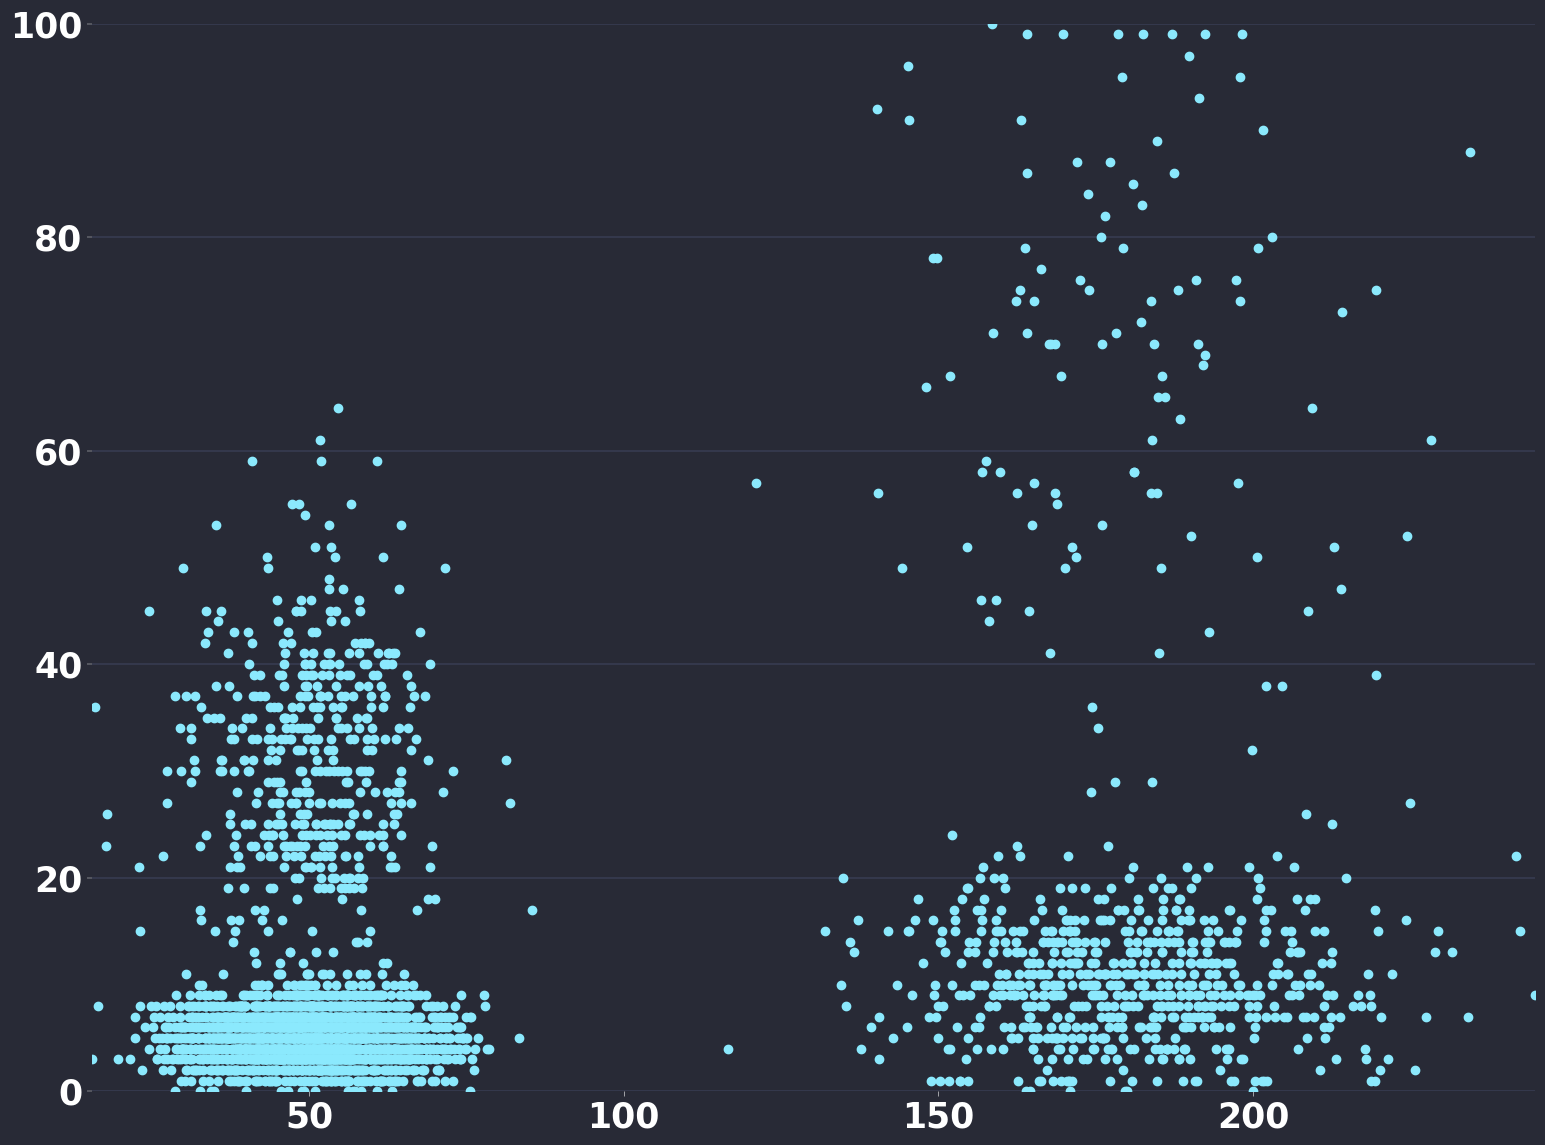

In [3]:
sp = pl.ScatterPlot(dr_df['distance_feature'], dr_df['speeding_feature'])
pl.SubPlot([[sp]]).plot()

In [4]:
starting_centroid_x_vals = [-0.5, 2, -0.5, 2]
starting_centroid_y_vals = [-1, 0, 2, 4]
sl.full_k_means(dr_df, 'distance_feature', 'speeding_feature', starting_centroid_x_vals, starting_centroid_y_vals, 1)
dr_df

,driver_ID,distance_feature,speeding_feature,normalized_distance_feature,normalized_speeding_feature,distances_to_centroids,centroid_idx
0,3423311935,71.24,28.0,-0.089810,1.260613,"[0.495823375118109, 1.7112822807046755, 3.6592...",0
1,3423313212,52.53,25.0,-0.439773,1.041744,"[0.5289880000480242, 1.4463459589184409, 4.037...",0
2,3423313724,64.54,27.0,-0.215131,1.187656,"[0.46333674864184937, 1.6146121065082402, 3.78...",0
3,3423311373,55.69,22.0,-0.380666,0.822875,"[0.7527797057679195, 1.2313335419258176, 4.184...",0
4,3423310999,54.58,25.0,-0.401428,1.041744,"[0.5331158874914704, 1.4481189110392936, 4.015...",0
...,...,...,...,...,...,...,...
3995,3423310685,160.04,10.0,1.571155,-0.052602,"[2.6132106806679403, 2.0884162609125165, 4.389...",3
3996,3423312600,176.17,5.0,1.872860,-0.417383,"[3.0777637018089727, 2.3604160872669357, 4.741...",3
3997,3423312921,170.91,12.0,1.774474,0.093311,"[2.6928307552734956, 2.315974350628217, 4.2329...",3
3998,3423313630,176.14,5.0,1.872299,-0.417383,"[3.077335156950652, 2.359854959526475, 4.74162...",3


/Users/247304/Projects/clustering/plot_lib.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


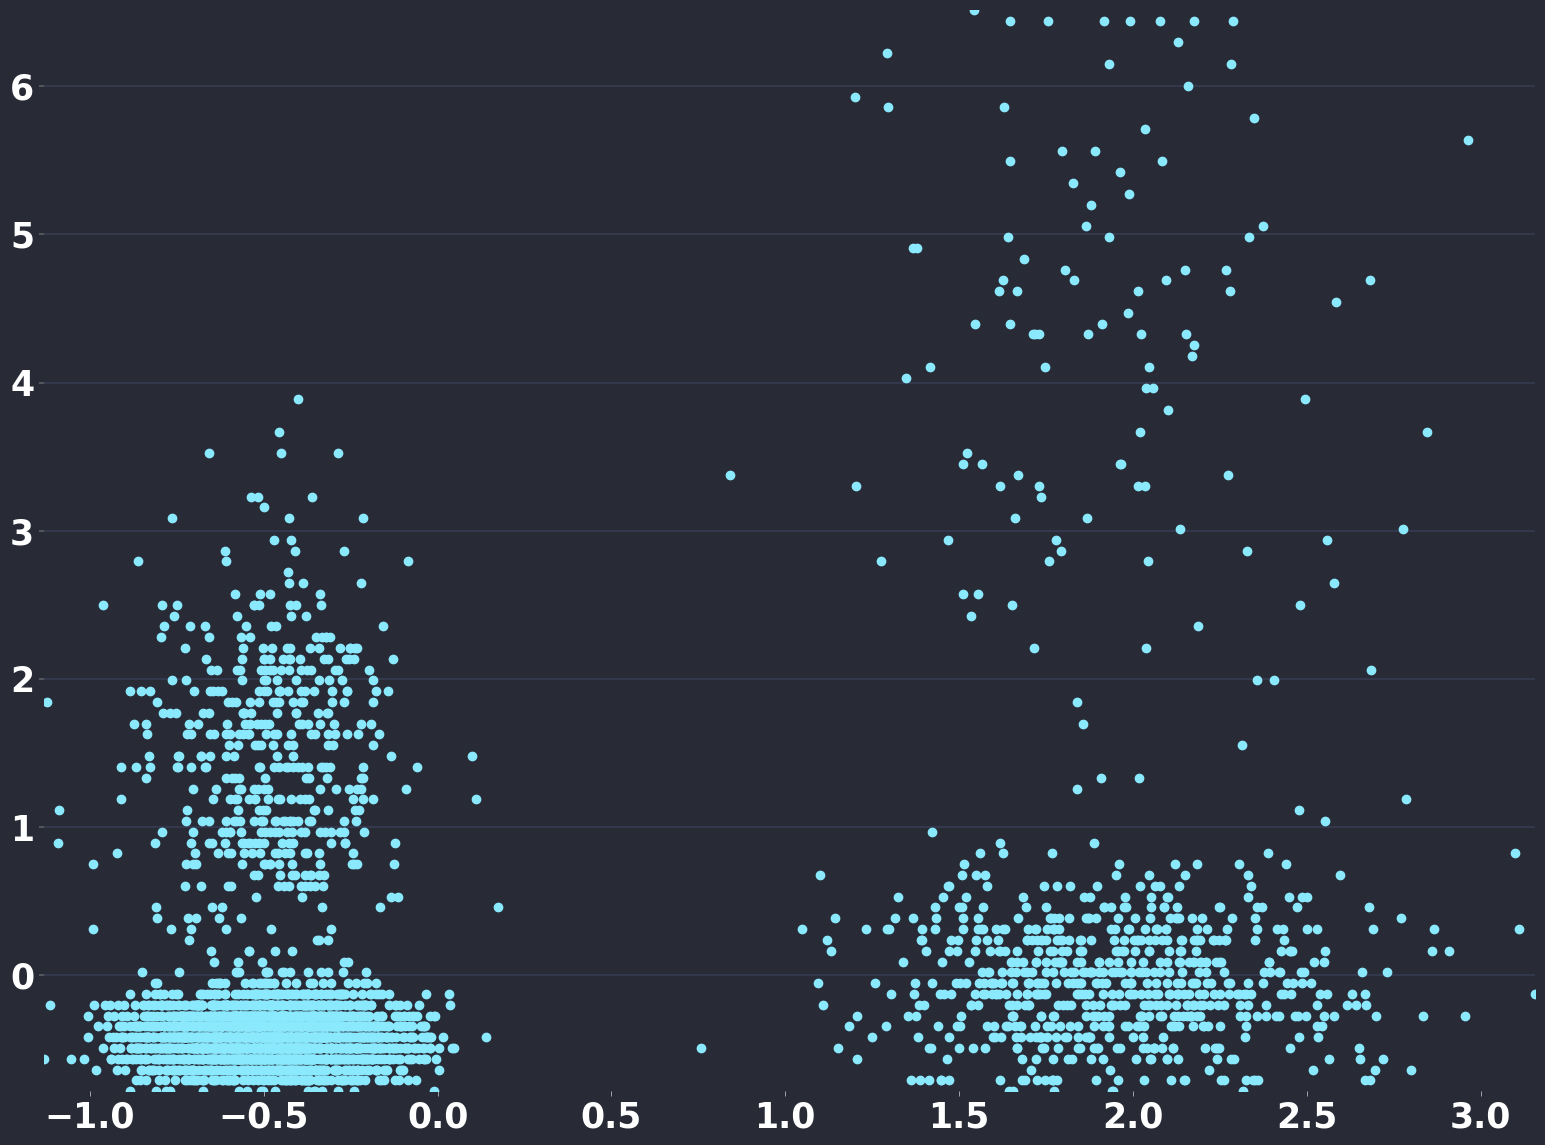

In [5]:
sp = pl.ScatterPlot(dr_df['normalized_distance_feature'], dr_df['normalized_speeding_feature'])
pl.SubPlot([[sp]]).plot()

/Users/247304/Projects/clustering/plot_lib.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


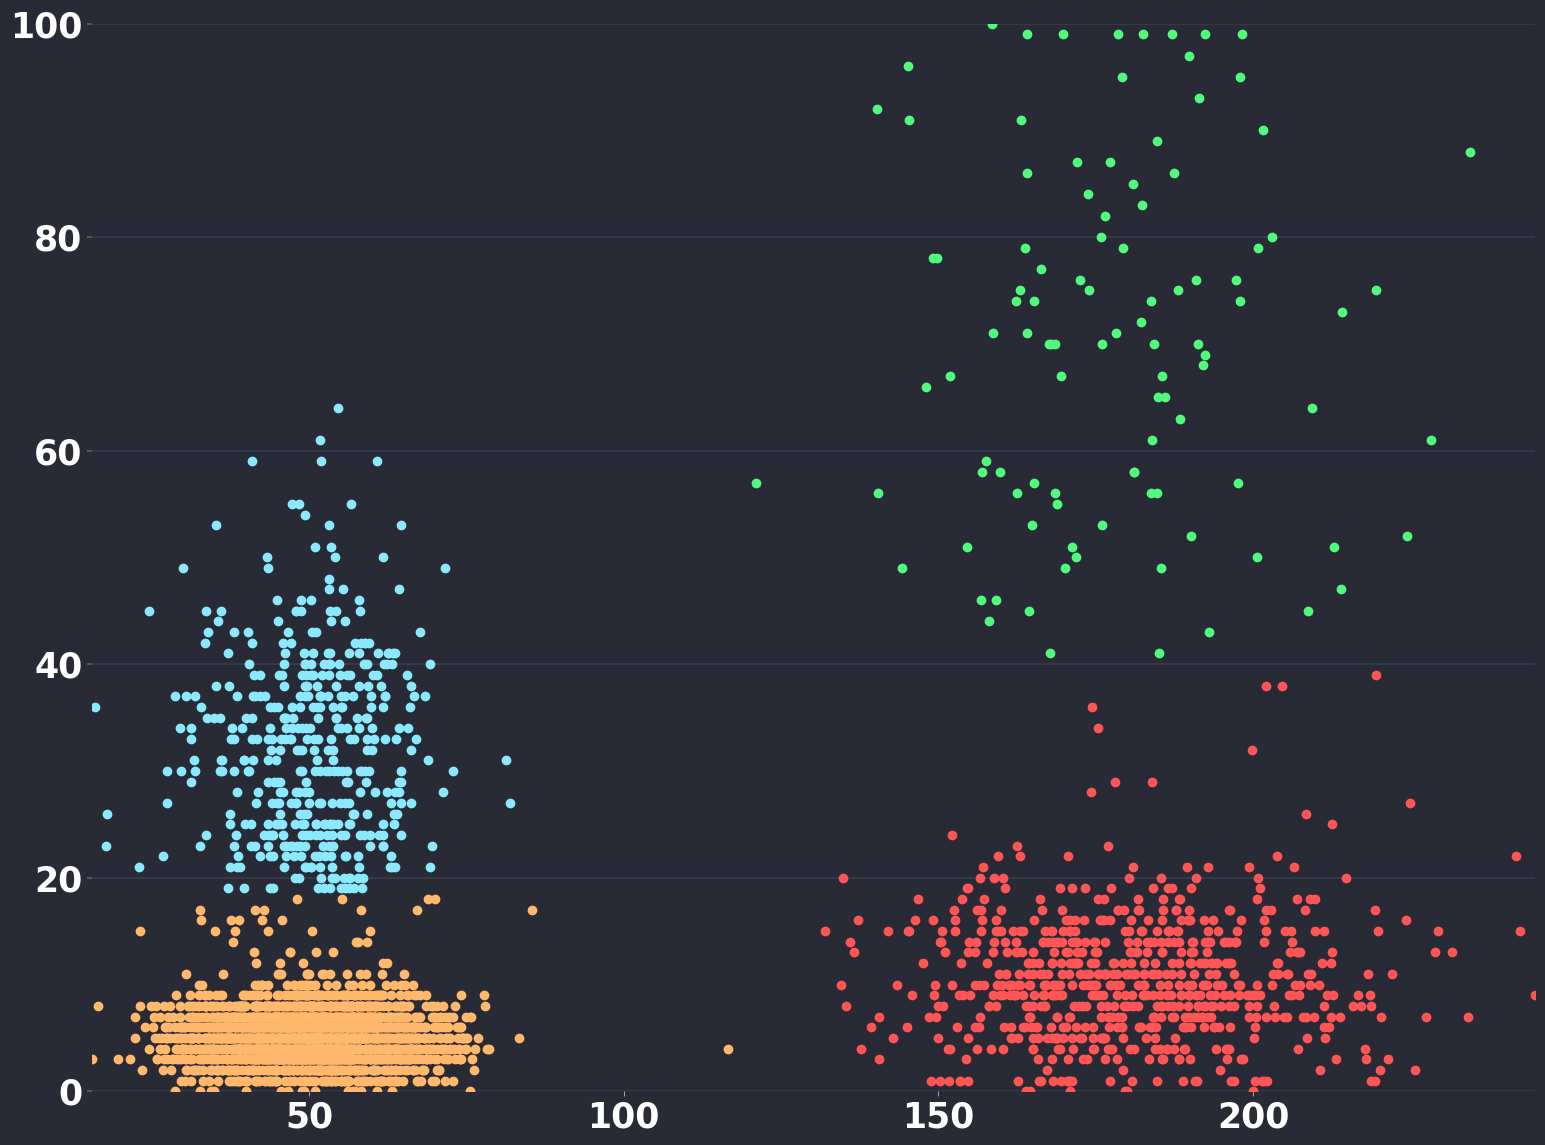

In [6]:
plots = []
for idx in dr_df['centroid_idx'].unique():
    rows = dr_df.query(f'centroid_idx=={idx}')
    x_vals = rows['distance_feature']
    y_vals = rows['speeding_feature']
    sp = pl.ScatterPlot(x_vals, y_vals)
    plots.append(sp)
pl.SubPlot([plots]).plot()
# dr_df